# Chapter: Business Features
## Feature Engineering & MLOps

**Strong feature engineering starts with understanding the business, not the code.** This
chapter teaches you to look at raw transactional data the way a business analyst would first,
and only THEN translate that understanding into engineered features — RFM, churn indicators,
fraud signals, and behavioral aggregates.

## Learning Objectives

By the end of this notebook, you should be able to:
- Explain the "raw data → business behavior → feature" mindset, and apply it to a new dataset
- Build RFM (Recency, Frequency, Monetary) features from a raw transactions table
- Engineer churn indicators from login and support-call history
- Engineer fraud signals from transaction timing and amount patterns
- Classify any feature as raw, derived, aggregate, or behavioral
- Propose 5 new features for a raw business dataset you haven't seen before

## Real-World Problem

You work at an e-commerce company with two raw data sources: a **transactions table** (every
purchase, ever) and a **customers table** (account info, login activity, support history). No
one has told you what "good features" look like — that's your job to figure out.

- **Raw data available:** `customer_id`, `transaction_date`, `transaction_amount`, `product_id`,
  `channel`, plus `login_count`, `support_calls`, `last_login_date` per customer.
- **Targets:** `churn` (will this customer leave?) and `is_fraud` (is this transaction
  fraudulent?) — two different business problems, same raw data sources.
- **Why the business cares:** a customer about to churn can be saved with a retention offer —
  IF you flag them in time. A fraudulent transaction costs real money — IF you catch it before
  it clears. Neither target is sitting in the data as a ready-made column; both have to be
  built from raw behavior.

## Why Do We Need This Concept?

**Analogy:** think of a doctor examining a patient. The doctor doesn't feed raw sensor readings
into a diagnosis machine — they first understand what "high blood pressure" or "irregular
heartbeat" MEANS medically, and only then decide which measurements to take and how to
interpret them. Feature engineering for business problems works the same way: you have to
understand what "churn risk" or "fraud" looks like as BEHAVIOR before you can decide which raw
columns to combine into a feature.

**What happens if we skip this step?** You end up feeding raw, unprocessed columns
(`transaction_date`, `login_count` as a single lifetime total) straight into a model, which
either can't use them at all (a date, on its own, means nothing) or uses them in misleading
ways (a customer with 40 total logins over 3 years looks identical to one with 40 logins in the
last month — even though one is clearly far more engaged right now).

## Concept Intuition

```
RAW DATA                    BUSINESS BEHAVIOR                    FEATURE
---------                   ------------------                   -------
transaction_date,     -->   "How recently did they      -->     recency_days
transaction_amount           buy, how often, how much?"          frequency
                                                                  monetary

last_login_date,       -->  "Have they quietly           -->     days_since_last_login
login_count                  stopped engaging?"                  declining_activity

transaction_date,      -->  "Are several transactions     -->    transaction_velocity_24h
transaction_amount           happening suspiciously        -->   unusual_amount
                              fast, or unusually large?"
```

Every feature in this chapter follows the same path: **raw column → what business behavior
does this represent? → what calculation captures that behavior?** Skipping the middle step is
how you end up with technically-valid but practically-useless features.

## Tiny Manual Example

Here are 6 raw transactions for ONE customer (customer #1), as of a snapshot date of
**2025-06-30**:

| transaction_date | transaction_amount |
|---|---|
| 2025-06-25 | 200 |
| 2025-05-10 | 150 |
| 2025-04-02 | 300 |
| 2025-02-18 | 100 |
| 2025-01-05 | 250 |
| 2024-11-20 | 180 |

**By hand, let's compute RFM:**
```
Recency  = days between snapshot (2025-06-30) and the MOST RECENT transaction (2025-06-25)
         = 5 days

Frequency = COUNT of transactions in this window = 6 transactions

Monetary = SUM of all transaction amounts
         = 200 + 150 + 300 + 100 + 250 + 180 = 1,180
```

That's it — three numbers, computed from six raw rows, that summarize "how recently, how
often, and how much" this customer engages. Compare this to a second customer whose most recent
transaction was 4 months ago, with only 2 transactions total — even without seeing their
`monetary` value, you'd already suspect they're far less engaged, just from recency and
frequency alone.

## Python Implementation

### Step 1 — Load the raw tables (two separate sources, as they'd really exist)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

customers = pd.read_csv("../data/raw/customers.csv", parse_dates=["signup_date", "last_login_date"])
transactions = pd.read_csv("../data/raw/transactions.csv", parse_dates=["transaction_date"])

SNAPSHOT_DATE = pd.Timestamp("2025-06-30")   # "today" -- when we're building features

print("customers:", customers.shape)
print("transactions:", transactions.shape)
customers.head(3)

customers: (200, 6)
transactions: (4778, 8)


,customer_id,signup_date,last_login_date,login_count,support_calls,churn
0,1,2023-09-21,2025-06-27,39,1,0
1,2,2024-07-08,2025-06-26,36,1,0
2,3,2024-08-20,2025-04-23,3,3,1


In [2]:
transactions.head(3)

,transaction_id,customer_id,transaction_date,transaction_amount,product_id,channel,transaction_status,is_fraud
0,5,1,2025-01-05,2178.21,P6,Mobile App,Success,0
1,12,1,2025-01-22,2379.63,P9,Mobile App,Success,0
2,3,1,2025-01-30,3777.71,P7,Mobile App,Failed,0


### Step 2 — RFM features (Recency, Frequency, Monetary)

**WHY?** RFM is one of the oldest, most reliable ways to summarize customer engagement from
transaction history alone — it's simple, interpretable, and works across almost any business
that has transactions.
**WHAT?** Three numbers per customer, each capturing a different dimension of engagement.
**HOW?** Aggregate the transactions table, grouped by customer.

In [3]:
rfm = transactions.groupby("customer_id").agg(
    recency_days=("transaction_date", lambda x: (SNAPSHOT_DATE - x.max()).days),
    frequency=("transaction_id", "count"),
    monetary=("transaction_amount", "sum"),
).reset_index()

rfm.head()

,customer_id,recency_days,frequency,monetary
0,1,0,22,61366.04
1,2,6,19,27011.21
2,3,65,9,17617.17
3,4,60,13,16353.10
4,5,9,26,12736.85


In [4]:
# Merge RFM onto the customers table so we can compare against churn
customer_features = customers.merge(rfm, on="customer_id", how="left")

print("RFM averages, split by churn status:")
customer_features.groupby("churn")[["recency_days", "frequency", "monetary"]].mean().round(1)

RFM averages, split by churn status:


,recency_days,frequency,monetary
churn,,,
0,6.0,28.2,48710.7
1,66.3,9.8,19028.5


**What to notice:** churned customers show much HIGHER recency (they haven't bought in a
while), much LOWER frequency, and much LOWER total spend — exactly the pattern RFM is designed
to surface. This isn't a coincidence for our synthetic data; it's the same pattern you'd expect
to see (and should go looking for) in real customer data.

### Step 3 — Churn indicators

**WHY?** A customer rarely churns overnight — it's usually a slow fade: fewer logins, more
complaints, less recent activity. These features try to catch that fade EARLY, while there's
still time to act.
**WHAT?** `days_since_last_login`, `support_call_frequency`, `declining_activity`, `tenure`.
**HOW?**

In [5]:
customer_features["tenure_days"] = (SNAPSHOT_DATE - customer_features["signup_date"]).dt.days
customer_features["days_since_last_login"] = (SNAPSHOT_DATE - customer_features["last_login_date"]).dt.days

# support_call_frequency: calls per day of tenure (a customer with 5 calls in 60 days is
# a much bigger red flag than 5 calls in 600 days)
customer_features["support_call_frequency"] = (
    customer_features["support_calls"] / customer_features["tenure_days"].clip(lower=1)
)

# declining_activity: compare transactions in the last 30 days vs. the 30 days before that
last_30 = transactions[transactions["transaction_date"] >= SNAPSHOT_DATE - pd.Timedelta(days=30)]
prior_30 = transactions[
    (transactions["transaction_date"] < SNAPSHOT_DATE - pd.Timedelta(days=30)) &
    (transactions["transaction_date"] >= SNAPSHOT_DATE - pd.Timedelta(days=60))
]
count_last_30 = last_30.groupby("customer_id").size().rename("txns_last_30d")
count_prior_30 = prior_30.groupby("customer_id").size().rename("txns_prior_30d")

customer_features = customer_features.merge(count_last_30, on="customer_id", how="left")
customer_features = customer_features.merge(count_prior_30, on="customer_id", how="left")
customer_features[["txns_last_30d", "txns_prior_30d"]] = customer_features[["txns_last_30d", "txns_prior_30d"]].fillna(0)

# declining_activity = 1 if recent activity dropped compared to the prior period
customer_features["declining_activity"] = (
    customer_features["txns_last_30d"] < customer_features["txns_prior_30d"]
).astype(int)

customer_features[["customer_id", "tenure_days", "days_since_last_login",
                    "support_call_frequency", "declining_activity", "churn"]].head()

,customer_id,tenure_days,days_since_last_login,support_call_frequency,declining_activity,churn
0,1,648,3,0.001543,0,0
1,2,357,4,0.002801,0,0
2,3,314,68,0.009554,0,1
3,4,440,70,0.013636,1,1
4,5,616,1,0.003247,0,0


In [6]:
print("Churn indicators, split by actual churn status:")
customer_features.groupby("churn")[
    ["days_since_last_login", "support_call_frequency", "declining_activity"]
].mean().round(3)

Churn indicators, split by actual churn status:


,days_since_last_login,support_call_frequency,declining_activity
churn,,,
0,6.373,0.003,0.366
1,69.128,0.011,0.128


**What to notice:** every single churn indicator moves in the expected direction for
churned customers — longer since their last login, more frequent support calls relative to how
long they've been a customer, and a much higher rate of declining recent activity. No single
feature tells the whole story, but together they paint a clear picture.

### Step 4 — Fraud signals

**WHY?** Fraud doesn't look like normal behavior — it looks like normal behavior sped up and
exaggerated. A genuine customer doesn't usually make five purchases in ten minutes, or spend
8x their usual amount in one transaction.
**WHAT?** `transaction_velocity_24h`, `unusual_amount`, `failed_transaction_count`.
**HOW?**

In [7]:
# transaction_velocity_24h: how many transactions did THIS customer make in the 24 hours
# BEFORE each transaction? (a rolling, per-transaction count -- not a single customer-level number)
transactions_sorted = transactions.sort_values(["customer_id", "transaction_date"]).reset_index(drop=True)

velocity = []
for cust_id, group in transactions_sorted.groupby("customer_id"):
    dates = group["transaction_date"].values
    counts = []
    for i, d in enumerate(dates):
        window_start = d - np.timedelta64(24, "h")
        count_in_window = ((dates > window_start) & (dates <= d)).sum()
        counts.append(count_in_window)
    velocity.extend(counts)

transactions_sorted["transaction_velocity_24h"] = velocity

print("Average 24h velocity, fraud vs. non-fraud transactions:")
print(transactions_sorted.groupby("is_fraud")["transaction_velocity_24h"].mean().round(2))

Average 24h velocity, fraud vs. non-fraud transactions:
is_fraud
0    1.17
1    2.59
Name: transaction_velocity_24h, dtype: float64


In [8]:
# unusual_amount: how many standard deviations is THIS transaction away from
# THIS customer's own typical spend? (a per-customer z-score, not a global one --
# a $2,000 transaction is normal for a big spender and wildly unusual for a small one)
customer_avg = transactions_sorted.groupby("customer_id")["transaction_amount"].transform("mean")
customer_std = transactions_sorted.groupby("customer_id")["transaction_amount"].transform("std")
transactions_sorted["unusual_amount"] = (
    (transactions_sorted["transaction_amount"] - customer_avg) / customer_std.replace(0, 1)
)

print("Average unusual_amount z-score, fraud vs. non-fraud transactions:")
print(transactions_sorted.groupby("is_fraud")["unusual_amount"].mean().round(2))

Average unusual_amount z-score, fraud vs. non-fraud transactions:
is_fraud
0   -0.01
1    2.06
Name: unusual_amount, dtype: float64


In [9]:
# failed_transaction_count: total failed attempts per customer (a burst of failed
# transactions right before a successful one is itself a common fraud pattern)
failed_counts = (
    transactions[transactions["transaction_status"] == "Failed"]
    .groupby("customer_id").size().rename("failed_transaction_count")
)
customer_features = customer_features.merge(failed_counts, on="customer_id", how="left")
customer_features["failed_transaction_count"] = customer_features["failed_transaction_count"].fillna(0)

customer_features[["customer_id", "failed_transaction_count"]].describe()

,customer_id,failed_transaction_count
count,200.000000,200.000000
mean,100.500000,1.390000
std,57.879185,1.310146
min,1.000000,0.000000
25%,50.750000,0.000000
50%,100.500000,1.000000
75%,150.250000,2.000000
max,200.000000,5.000000


**What to notice:** fraud transactions show dramatically higher `transaction_velocity_24h`
(several transactions bunched into a short window) AND a much higher `unusual_amount` z-score
(far larger than this specific customer's own normal spend) — both computed relative to the
customer's OWN history, not some global average, which is exactly what makes them useful:
a genuinely high-spending customer's large transactions won't falsely trigger these signals.

### Step 5 — Behavioral aggregates

**WHY?** A single lifetime total (e.g., "40 logins ever") hides WHEN that activity happened.
Windowed aggregates (7-day, 30-day) capture RECENT behavior, which is almost always more
predictive than all-time totals.
**WHAT?** `average_transaction_amount`, `transaction_count_7d`, `transaction_count_30d`.
**HOW?**

In [10]:
cutoff_7 = SNAPSHOT_DATE - pd.Timedelta(days=7)
cutoff_30 = SNAPSHOT_DATE - pd.Timedelta(days=30)

count_7d = transactions[transactions["transaction_date"] >= cutoff_7].groupby("customer_id").size().rename("transaction_count_7d")
count_30d = transactions[transactions["transaction_date"] >= cutoff_30].groupby("customer_id").size().rename("transaction_count_30d")
avg_amount = transactions.groupby("customer_id")["transaction_amount"].mean().rename("average_transaction_amount")

for feat in [count_7d, count_30d, avg_amount]:
    customer_features = customer_features.merge(feat, on="customer_id", how="left")

customer_features[["transaction_count_7d", "transaction_count_30d"]] = (
    customer_features[["transaction_count_7d", "transaction_count_30d"]].fillna(0)
)

customer_features[["customer_id", "average_transaction_amount",
                    "transaction_count_7d", "transaction_count_30d", "churn"]].head()

,customer_id,average_transaction_amount,transaction_count_7d,transaction_count_30d,churn
0,1,2789.365455,3.0,5.0,0
1,2,1421.642632,2.0,6.0,0
2,3,1957.463333,0.0,0.0,1
3,4,1257.930769,0.0,0.0,1
4,5,489.878846,0.0,5.0,0


## Visualization

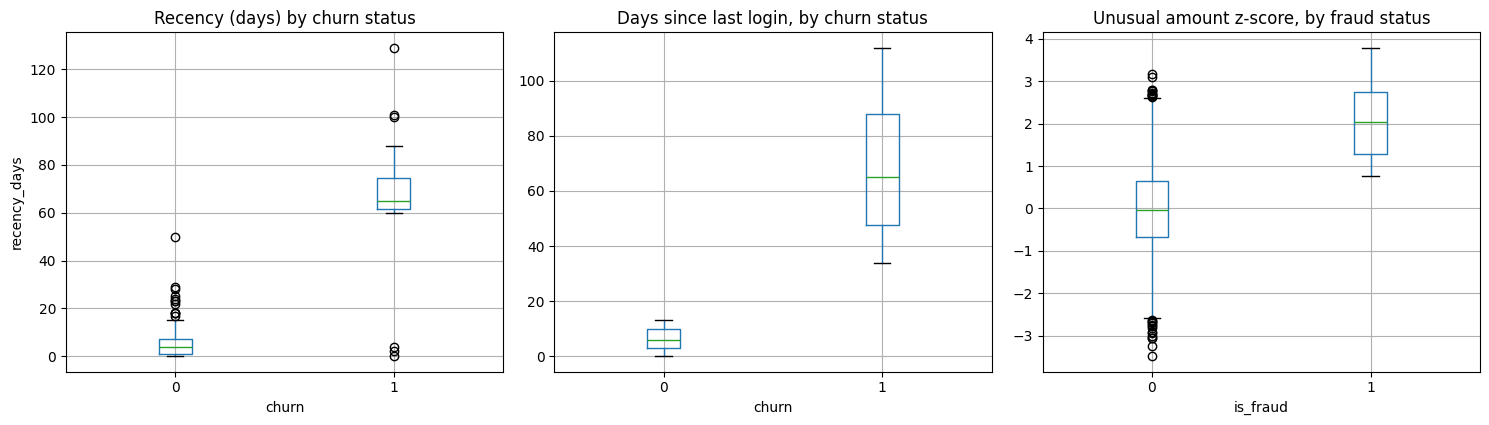

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

customer_features.boxplot(column="recency_days", by="churn", ax=axes[0])
axes[0].set_title("Recency (days) by churn status")
axes[0].set_xlabel("churn"); axes[0].set_ylabel("recency_days")

customer_features.boxplot(column="days_since_last_login", by="churn", ax=axes[1])
axes[1].set_title("Days since last login, by churn status")
axes[1].set_xlabel("churn")

transactions_sorted.boxplot(column="unusual_amount", by="is_fraud", ax=axes[2])
axes[2].set_title("Unusual amount z-score, by fraud status")
axes[2].set_xlabel("is_fraud")

plt.suptitle("")
plt.tight_layout()
plt.show()

**What should you notice?** Each boxplot shows a clean separation between the two groups —
this is exactly the signal a model needs to actually learn the pattern, rather than guess.
Real business data is rarely this clean, but the SHAPE of the separation (churned/fraud cases
skewing toward one side) is what you should be hunting for when evaluating a new feature.

## Feature Classification

Every feature we built falls into one of four categories — being able to name which is which
helps you reason about maintenance cost, freshness requirements, and reuse potential (a theme
we'll return to in the Feature Metadata chapter):

| Feature | Category | Why |
|---|---|---|
| `transaction_amount` | Raw | Straight from the source table, untouched |
| `tenure_days` | Derived | One simple calculation from two raw columns (dates) |
| `recency_days`, `frequency`, `monetary` | Aggregate | Computed by grouping/summarizing MANY raw rows into one number per customer |
| `declining_activity` | Behavioral | Captures a PATTERN over time (comparing two periods), not just a single summary statistic |
| `transaction_velocity_24h` | Behavioral | Captures a time-based BEHAVIOR pattern (bursts of activity), not a static aggregate |
| `unusual_amount` | Derived + Behavioral | Derived from raw amount, but specifically designed to capture deviation from normal BEHAVIOR |

## Industry Case Study

**Banking — credit card fraud detection.** A bank's fraud team doesn't feed raw transaction
logs into a model. They engineer exactly the kind of behavioral features built in this chapter:
`transaction_velocity_1h`, `distance_from_last_transaction_location`,
`amount_vs_customer_average`, `is_new_merchant_category`. None of these exist as raw columns —
each one encodes a specific, well-understood FRAUD BEHAVIOR pattern that the fraud team already
knew to look for before any model was built.

```
RAW DATA                    BUSINESS BEHAVIOR                  FEATURE                MODEL           DECISION
---------                   ------------------                  -------                -----           --------
transaction logs      -->   "is this spending burst      -->   transaction_velocity  -> fraud    -->  block / flag
(timestamp, amount,          unusual for THIS customer,         unusual_amount           score          for review
merchant, location)          not just unusual in general?"      (per-customer, not
                                                                  global average)
```

The single biggest lesson banks have learned the hard way: a GLOBAL threshold ("flag any
transaction over ₹50,000") misses fraud on small accounts and over-flags legitimate large
purchases on big-spending accounts. Every fraud signal that actually works is calibrated
PER-CUSTOMER, exactly like our `unusual_amount` z-score above.

## What Can Go Wrong?

**Mistake 1 — Using lifetime totals instead of recent windows**

- **Problem:** `login_count` as an all-time total treats a customer who logged in 40 times
  three years ago identically to one who logged in 40 times last month.
- **Why it happens:** lifetime totals are the easiest number to pull from a database — no date
  filtering required.
- **Example:** two customers both show `login_count = 40`, but one is actively engaged and one
  hasn't logged in for 6 months.
- **How to detect it:** check whether any "count" or "total" feature has a date range attached
  to it — if not, ask what time period it silently covers.
- **How to fix it:** always prefer windowed aggregates (`login_count_30d`,
  `transaction_count_7d`) over unbounded lifetime totals for anything meant to reflect CURRENT
  behavior.

**Mistake 2 — Global thresholds instead of per-customer baselines**

- **Problem:** flagging "any transaction over ₹10,000" as unusual ignores that ₹10,000 is
  completely normal for some customers and wildly unusual for others.
- **Why it happens:** a single global rule is simpler to write and explain than a per-customer
  calculation.
- **Example:** a global threshold either misses fraud on high-value accounts (their fraud
  amounts don't look unusual GLOBALLY) or constantly false-alarms on legitimate large purchases
  by big spenders.
- **How to detect it:** check whether a "usual/unusual" feature is computed against a fixed
  number or against each customer's own history.
- **How to fix it:** compute deviation features (like `unusual_amount`) relative to each
  customer's own mean and standard deviation, exactly as we did above.

**Mistake 3 — Building a feature nobody asked for the right question about**

- **Problem:** engineering a technically sophisticated feature that doesn't actually map to any
  real business behavior anyone recognizes.
- **Why it happens:** it's tempting to build clever features (polynomial combinations,
  complex ratios) without first confirming a business behavior justifies them.
- **Example:** creating `login_count² / support_calls` because it's mathematically interesting,
  without a business reason to believe THAT specific combination reflects anything real.
- **How to detect it:** if you can't explain, in one plain-English sentence, what business
  behavior a feature represents, that's a warning sign.
- **How to fix it:** always start from the business behavior (as this whole chapter has
  emphasized) and work TOWARD the calculation — never the other way around.

## Mini Exercise

**Try this yourself before looking at the solution.**

You're given a raw dataset for a video streaming service: `customer_id`, `watch_date`,
`watch_duration_minutes`, `content_id`, `device_type`, plus a customer table with
`subscription_start_date` and `plan_type`. Propose ONE feature for each of these business
questions:
1. Is this customer's engagement declining?
2. Is this customer getting strong value for their subscription price?
3. Is this viewing session unusual compared to this customer's normal habits?

## Exercise Solution

1. **Declining engagement:** `watch_hours_30d` vs. `watch_hours_prior_30d` — the same
   "compare two windows" pattern as `declining_activity` above. A customer whose recent watch
   hours have dropped compared to the period before is showing early disengagement.

2. **Value for subscription price:** `total_watch_hours_30d / plan_price` — a behavioral
   ratio connecting raw usage to what they're paying, similar in spirit to
   `average_transaction_amount`. A customer paying for premium but barely watching anything is
   a churn risk for a completely different reason than a disengaged free-tier customer.

3. **Unusual viewing session:** `session_duration_zscore` — this session's
   `watch_duration_minutes`, compared to THIS customer's own average and standard deviation
   (exactly the `unusual_amount` pattern) — not a global average across all customers, since
   "normal" viewing habits vary enormously from person to person.

## Interview Questions

**1. (Conceptual) Why do RFM features work well across so many different industries?**
> Because "how recently, how often, how much" captures the core of customer engagement
> regardless of the specific business — it applies to retail, banking, subscription services,
> and more, without needing industry-specific logic.

**2. (Practical) Why is `days_since_last_login` usually more useful than `total_login_count`
for predicting churn?**
> Recency captures CURRENT engagement state; a lifetime total can look identical for an actively
> engaged customer and one who's gone quiet, since it doesn't reveal WHEN the activity happened.

**3. (Practical) Why should fraud thresholds be computed per-customer rather than globally?**
> Because "unusual" is relative — a transaction amount that's alarming for a typically
> low-spending customer may be completely normal for a high-spending one, and a single global
> threshold either misses the former or over-flags the latter.

**4. (Scenario) You're asked to build churn features for a gym membership business. What raw
data would you ask for first?**
> Check-in history (dates/times), membership start date, class booking history, payment
> history, and any support/complaint records — the same raw ingredients (activity over time,
> tenure, and friction signals) that drove churn indicators in this chapter, adapted to a gym's
> specific behaviors.

**5. (Conceptual) What's the difference between a "derived" feature and a "behavioral" feature?**
> A derived feature is a straightforward calculation from one or two raw columns (like
> `tenure_days` from a signup date). A behavioral feature captures a PATTERN over time or
> relative to a baseline (like `declining_activity` or `unusual_amount`) — it requires
> reasoning about behavior, not just arithmetic.

**6. (Practical) Why aggregate transactions instead of feeding raw transaction rows into a model?**
> A model needs ONE row per prediction target (e.g., one row per customer for churn). Raw
> transactions are many rows per customer — they must be aggregated into summary features
> before they fit a standard tabular model.

**7. (Scenario) Your fraud model flags a customer's transaction as fraud because it's larger
than their historical average. The customer says they're simply making a special one-time
purchase (a wedding gift). Is the feature wrong?**
> No — the feature is doing exactly what it's designed to do: flag something UNUSUAL for
> review. Unusual doesn't always mean fraudulent; that's why such flags typically route to
> human review rather than automatically blocking the transaction.

**8. (Conceptual) Why does this chapter emphasize "understand the business" before writing any
code?**
> Because a feature engineered without understanding what behavior it's meant to represent is
> either useless or actively misleading — the calculation is only as good as the business
> reasoning behind it.

## Assignment (30-60 minutes)

Using `transactions.csv` and `customers.csv` from this chapter:

1. Build ONE new RFM-style feature: `monetary_last_90d` (total spend in the last 90 days only,
   rather than all-time).
2. Build ONE new churn indicator: `login_frequency` = `login_count / tenure_days`.
3. Compare both new features' average values for churned vs. non-churned customers — do they
   separate the two groups as cleanly as the features already in this notebook?
4. Classify both new features (raw / derived / aggregate / behavioral) and justify your answer
   in one sentence each.

## Key Takeaways

- Strong feature engineering starts with understanding business BEHAVIOR, not with writing code.
- RFM (Recency, Frequency, Monetary) is a simple, reliable way to summarize engagement from any
  transaction history.
- Prefer recent, windowed aggregates over unbounded lifetime totals when the goal is capturing
  CURRENT behavior.
- Fraud and "unusual" signals should be calibrated per-entity (per-customer), not against a
  single global threshold.
- Every feature falls into one of four categories — raw, derived, aggregate, behavioral —
  knowing which helps you reason about freshness, cost, and reuse.
- If you can't explain a feature's business meaning in one plain sentence, that's a signal to
  reconsider it before building it.

## Final Challenge

A ride-sharing company gives you raw data: `ride_id`, `customer_id`, `driver_id`, `ride_date`,
`fare_amount`, `pickup_location`, `dropoff_location`, `rating`, plus a customer table with
`signup_date` and `total_rides`. Propose 5 features spanning churn, fraud, and behavioral
aggregates — for each, state the business behavior it represents BEFORE writing the
calculation, following the exact "raw data → business behavior → feature" path this chapter
has emphasized throughout.